In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.manifold import TSNE, Isomap, MDS
from sklearn.preprocessing import MinMaxScaler

from sklearn.datasets import make_swiss_roll
# mnist 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from inverse_projections import ILAMP, NNinv, RBFinv, MDSinv, get_gradient_map

### Generate some data

In [2]:
# X, y = make_swiss_roll(n_samples=2000, noise=0.2, random_state=0, hole=False)

# ## scale the data to [0,1] is required for the NNinv
# scaler = MinMaxScaler()
# X = scaler.fit_transform(X)

# ## plot the original data
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')

# ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap=plt.cm.jet)

## MNIST
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.astype('float32')/255.0
y = y.astype('int64')


X, _, y, _ = train_test_split(X, y, train_size=2000, random_state=420) ## you may need to use all the data 

## select only 0 and 7 || or try 1 and 7
mask = (y == 0) | (y == 7)
X = np.array(X[mask])
y = np.array(y[mask])
print(X.shape, y.shape)


(403, 784) (403,)


### Build  $P$ and $P^{-1}$

c:\Users\yuwan\workspace\InverseProjections\.venv\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


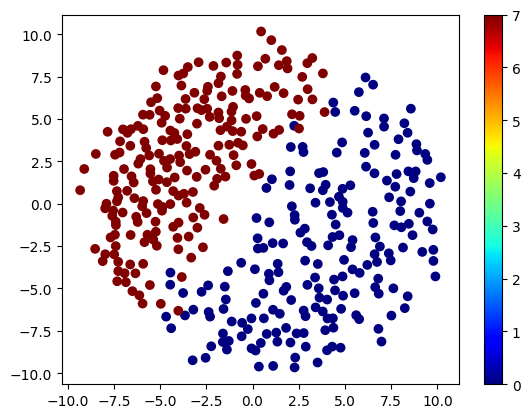

In [3]:
## P, using MDS
X2d = MDS(n_components=2, random_state=42, n_jobs=-1).fit_transform(X)

plt.scatter(X2d[:,0], X2d[:,1], c=y, cmap=plt.cm.jet)
# cbar
plt.colorbar()

In [4]:
## Pinv with ilamp
ilamp = ILAMP(k=6)
ilamp.fit(X2d, X)

## Pinv with NNinv
nninv = NNinv(dims=[2048, 2048, 2048, 2048],) ## this structure is according the original paper, but it seems too large for most of the datasets we teset (like any 3D dataset, or the MNIST). But it works
nninv.fit(X2d, X, epochs=50)

## Pinv with RBF
rbf = RBFinv()
rbf.fit(X2d, X)

## MDSinv
mdsinv = MDSinv()
mdsinv.fit(X2d, X)

device:  cpu
Epoch 1/50, Loss: 0.15831071
Epoch 2/50, Loss: 0.09432253
Epoch 3/50, Loss: 0.08638142
Epoch 4/50, Loss: 0.07421396
Epoch 5/50, Loss: 0.07010611
Epoch 6/50, Loss: 0.06829753
Epoch 7/50, Loss: 0.06598341
Epoch 8/50, Loss: 0.06409837
Epoch 9/50, Loss: 0.05974656
Epoch 10/50, Loss: 0.05568562
Epoch 11/50, Loss: 0.05473306
Epoch 12/50, Loss: 0.05379379
Epoch 13/50, Loss: 0.05308102
Epoch 14/50, Loss: 0.05237337
Epoch 15/50, Loss: 0.05151978
Epoch 16/50, Loss: 0.05010980
Epoch 17/50, Loss: 0.04806755
Epoch 18/50, Loss: 0.04672928
Epoch 19/50, Loss: 0.04552525
Epoch 20/50, Loss: 0.04442256
Epoch 21/50, Loss: 0.04358656
Epoch 22/50, Loss: 0.04292874
Epoch 23/50, Loss: 0.04253304
Epoch 24/50, Loss: 0.04252802
Epoch 25/50, Loss: 0.04236604
Epoch 26/50, Loss: 0.04142689
Epoch 27/50, Loss: 0.04074107
Epoch 28/50, Loss: 0.03994096
Epoch 29/50, Loss: 0.03980279
Epoch 30/50, Loss: 0.03937346
Epoch 31/50, Loss: 0.03894490
Epoch 32/50, Loss: 0.03886657
Epoch 33/50, Loss: 0.03862841
Epoch 

### Inverse proejction some 2D points

In [ ]:
## sample some points in the 2D space

xmin, xmax = X2d[:,0].min(), X2d[:,0].max()
ymin, ymax = X2d[:,1].min(), X2d[:,1].max()

x_ = np.linspace(xmin, xmax, 10)
y_ = np.linspace(ymin, ymax, 10)

xx, yy = np.meshgrid(x_, y_)
samples = np.c_[xx.ravel(), yy.ravel()]

## Pinv with ilamp
samples_ilamp = ilamp.transform(samples)

## Pinv with NNinv
samples_nninv = nninv.transform(samples)

## Pinv with RBF
samples_rbf = rbf.transform(samples)

## MDSinv
samples_mdsinv = mdsinv.transform(samples)

100%|██████████| 1/1 [00:00<00:00, 1085.48it/s]


Text(0.5, 0.98, 'MDSinv')

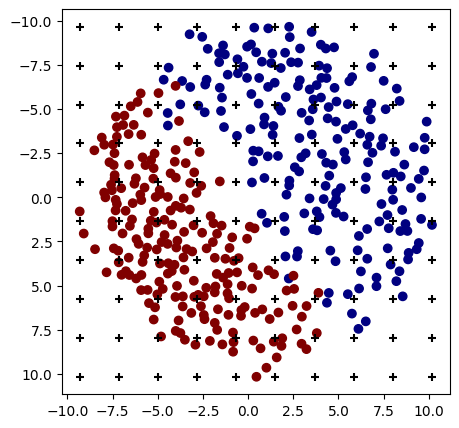

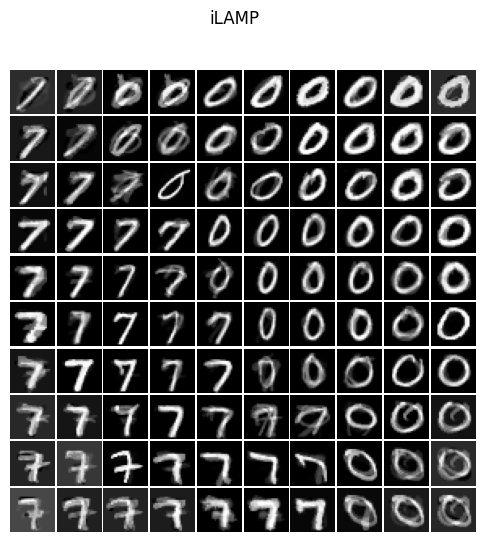

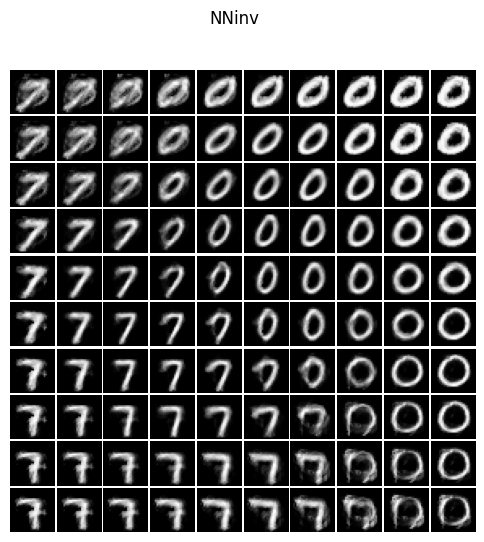

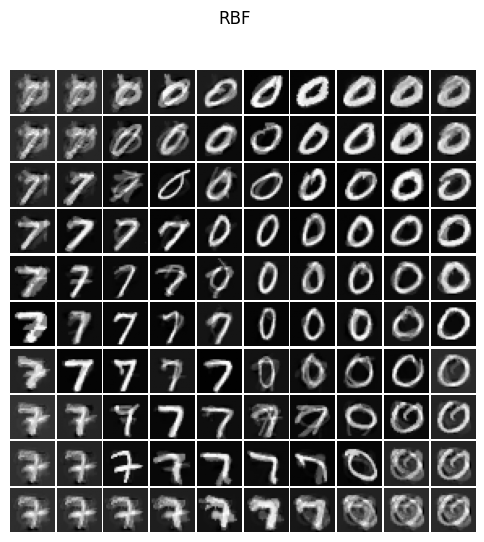

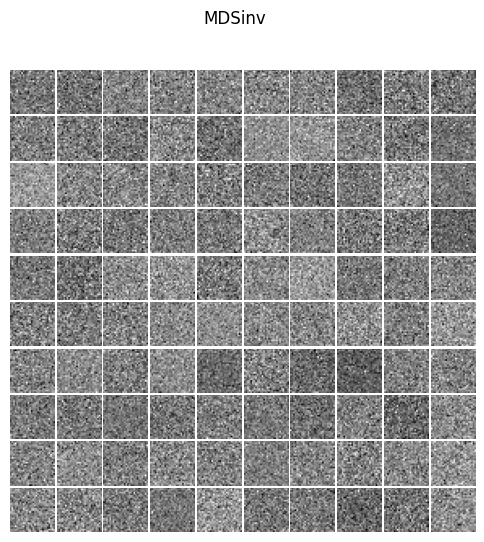

In [12]:
## plot the results
fig, ax = plt.subplots(1, 1, figsize=(5,5))
ax.scatter(X2d[:,0], X2d[:,1], c=y, cmap=plt.cm.jet)
ax.scatter(samples[:,0], samples[:,1], c='black', marker='+')
ax.invert_yaxis()

## results of ilamp
fig1, axes = plt.subplots(10, 10, figsize=(6,6))
fig1.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(100):
    ax = axes[i//10, i%10]
    ax.imshow(samples_ilamp[i].reshape(28,28), cmap='gray')
    ax.axis('off')
fig1.suptitle('iLAMP')

## results of NNinv
fig2, axes = plt.subplots(10, 10, figsize=(6,6))
fig2.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(100):
    ax = axes[i//10, i%10]
    ax.imshow(samples_nninv[i].reshape(28,28), cmap='gray')
    ax.axis('off')
fig2.suptitle('NNinv', )

## results of RBF
fig3, axes = plt.subplots(10, 10, figsize=(6,6))
fig3.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(100):
    ax = axes[i//10, i%10]
    ax.imshow(samples_rbf[i].reshape(28,28), cmap='gray')
    ax.axis('off')
fig3.suptitle('RBF')


## results of MDSinv
fig5, axes = plt.subplots(10, 10, figsize=(6,6))
fig5.subplots_adjust(hspace=0.05, wspace=0.05)
for i in range(100):
    ax = axes[i//10, i%10]
    ax.imshow(samples_mdsinv[i].reshape(28,28), cmap='gray')
    ax.axis('off')

fig5.suptitle('MDSinv')

### compute gradient maps

In [8]:
inv_methods = {
    'iLAMP': ilamp,
    'NNInv': nninv,
    'RBF': rbf,
    # 'MDSinv': mdsinv,
    # 'mdsinv_closest': mdsinv_closet
}

map_grid = 100

grad_map_dict = {}
nD_grids_dict = {}
global_min = 1e10
global_max = -1e10
for name, inv in inv_methods.items():
    grad_map, nD_grid = get_gradient_map(inv, X2d, map_grid)
    grad_map_dict[name] = grad_map.reshape(map_grid, map_grid)
    print(min(grad_map), max(grad_map))
    global_min = min(global_min, min(grad_map))
    global_max = max(global_max, max(grad_map))
    nD_grids_dict[name] = nD_grid

100%|██████████| 404/404 [00:00<00:00, 193701.28it/s]


18.56219083107382 617.3578701490563
9.984469 94.589355


100%|██████████| 11/11 [00:00<00:00, 126.10it/s]


24.420336875731333 483.1433036704984


0.014122649109974402 1.0
0.0 0.13929633535744432
0.023767697835462738 0.7790246225533174


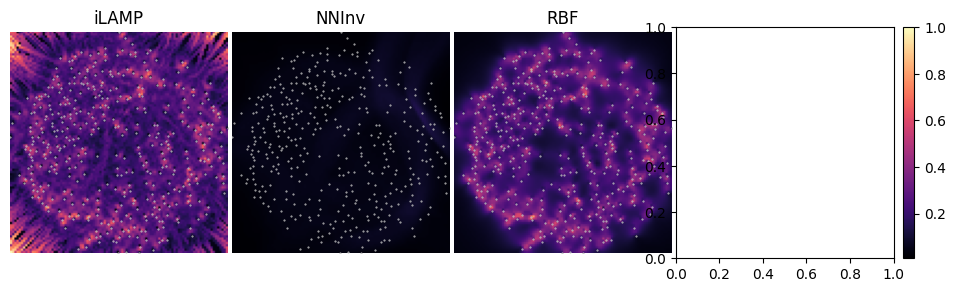

In [9]:

fig, axes = plt.subplots(1, 4, figsize=(12,3))

# white space
fig.subplots_adjust(wspace=0.02)

for i, (name, grad_map) in enumerate(grad_map_dict.items()):
    ax = axes[i]
    scaled_grad_map = (grad_map - global_min) / (global_max - global_min)
    print(scaled_grad_map.min(), scaled_grad_map.max())

    # flipp the x axis
    scaled_grad_map = np.flip(scaled_grad_map, axis=0)

    ### scaled individually
    # im = ax.imshow(scaled_grad_map, cmap='magma') ## this will rescale the data to [0,1]
    
    ## scaled globally
    image = cm.magma(scaled_grad_map)
    im = ax.imshow(image, cmap='magma', extent=[xmin, xmax, ymin, ymax])
    ax.set_title(name)
    ax.axis('off')
    ax.scatter(X2d[:,0], X2d[:,1], c='#BBBBBB', s=1, marker='.')

fig.colorbar(im,  ax=axes, orientation='vertical', fraction=0.04, pad=0.01, )


0.014122649109974402 1.0
0.0 0.13929633535744432
0.023767697835462738 0.7790246225533174


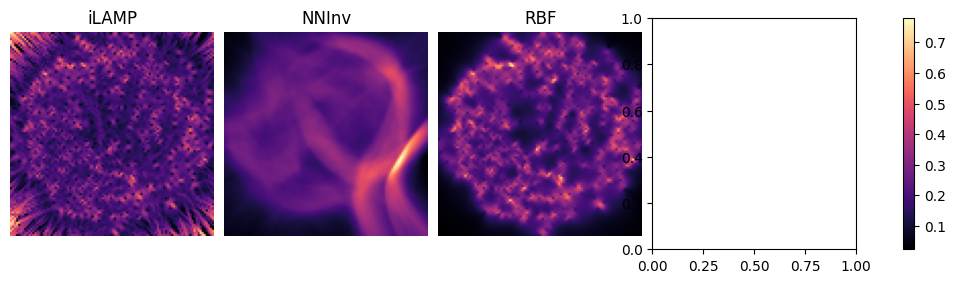

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(12,3))

# white space
fig.subplots_adjust(wspace=0.05)

for i, (name, grad_map) in enumerate(grad_map_dict.items()):
    ax = axes[i]
    scaled_grad_map = (grad_map - global_min) / (global_max - global_min)
    print(scaled_grad_map.min(), scaled_grad_map.max())

    ### scaled individually
    im = ax.imshow(scaled_grad_map, cmap='magma') ## this will rescale the data to [0,1]

    ## scaled globally
    # image = cm.magma(scaled_grad_map)
    # im = ax.imshow(image, cmap='magma')
    ax.set_title(name)
    ax.axis('off')



fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.04, )